# FER2013 — Data Exploration
**ML Davaleba 4 — Facial Expression Recognition Challenge**

ეს notebook აკეთებს:
1. Drive mount + project setup
2. Kaggle API authentication
3. FER2013 data ჩამოტვირთვა
4. Data exploration (class distribution, samples)
5. Train/val/test split-ის შენახვა


In [1]:
# 1. დავამაუნთოთ დრაივი
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
# 2. ფოლდერის სტრუქტურსი სეთაფი
import os

PROJECT_DIR = '/content/drive/MyDrive/ML_davaleba_4'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/data', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/notebooks', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/models', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/src', exist_ok=True)
os.chdir(PROJECT_DIR)
print(f"Working in: {os.getcwd()}")
print(os.listdir())

Working in: /content/drive/MyDrive/ML_davaleba_4
['data', 'notebooks', 'models', 'src']


In [3]:
# 3. პაკეტების გადმოწერა
!pip install -q wandb kaggle

## Kaggle Authentication


In [4]:
# 4. კეგლის ეიპიაისთან დაკავშირება
KAGGLE_TOKEN = "KGAT_70f1e2d64ad71f7554f7e71539b77d97"

import os
os.environ['KAGGLE_API_TOKEN'] = KAGGLE_TOKEN

!mkdir -p ~/.kaggle
!echo "$KAGGLE_API_TOKEN" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

!kaggle competitions list -s "facial expression" 2>&1 | head -5

ref                                                                                              deadline             category      reward  teamCount  userHasEntered  
-----------------------------------------------------------------------------------------------  -------------------  ---------  ---------  ---------  --------------  
https://www.kaggle.com/competitions/csc411f15-facial-expression-prediction                       2015-12-11 04:59:00  Community  Knowledge         97           False  
https://www.kaggle.com/competitions/ml-2024-fall-hw2                                             2024-10-18 16:00:00  Community      Kudos         91           False  
https://www.kaggle.com/competitions/facial-expression-recognition                                2020-11-04 23:59:00  Community      Kudos         69           False  


In [5]:
# 5. ვიწერთ ქომფეთიშენის დეითას
DATA_DIR = f'{PROJECT_DIR}/data'

if not os.path.exists(f'{DATA_DIR}/icml_face_data.csv'):
    print("Downloading FER2013 data...")
    !kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge -p $DATA_DIR
    print("Extracting...")
    !cd $DATA_DIR && unzip -q -o challenges-in-representation-learning-facial-expression-recognition-challenge.zip
    print("Done!")
else:
    print("Data already downloaded")

# Check files
!ls -lh $DATA_DIR

100% 285M/285M [00:03<00:00, 95.6MB/s]

Extracting...
Done!
total 952M
-rw------- 1 root root 286M Dec 11  2019 challenges-in-representation-learning-facial-expression-recognition-challenge.zip
-rw------- 1 root root 7.1K Dec 11  2019 example_submission.csv
-rw------- 1 root root  92M Dec 11  2019 fer2013.tar.gz
-rw------- 1 root root 288M Dec 11  2019 icml_face_data.csv
-rw------- 1 root root  58M Dec 11  2019 test.csv
-rw------- 1 root root 230M Dec 11  2019 train.csv


In [6]:
# 6. Extract fer2013.tar.gz (if present)
import os
if os.path.exists(f'{DATA_DIR}/fer2013.tar.gz') and not os.path.exists(f'{DATA_DIR}/fer2013/fer2013.csv'):
    !cd $DATA_DIR && tar -xzf fer2013.tar.gz
    print("Extracted fer2013.tar.gz")
!ls $DATA_DIR

Extracted fer2013.tar.gz
challenges-in-representation-learning-facial-expression-recognition-challenge.zip
example_submission.csv
fer2013
fer2013.tar.gz
icml_face_data.csv
test.csv
train.csv


## Data Loading & Exploration


In [7]:
# 7. ვალოუდებთ icml_face_data.csv
import pandas as pd
import numpy as np

df = pd.read_csv(f'{DATA_DIR}/icml_face_data.csv')
print(f"Total samples: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Total samples: 35887
Columns: ['emotion', ' Usage', ' pixels']


,emotion,Usage,pixels
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


In [8]:
# 8. ვჩექავთ column სახელებს
df.columns = df.columns.str.strip()
print(df.columns.tolist())
print()
print("Usage distribution:")
print(df['Usage'].value_counts())

['emotion', 'Usage', 'pixels']

Usage distribution:
Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64


In [9]:
# 9. ემოციების კლასების მაპი
EMOTION_LABELS = {
    0: 'Angry',
    1: 'Disgust',
    2: 'Fear',
    3: 'Happy',
    4: 'Sad',
    5: 'Surprise',
    6: 'Neutral'
}
NUM_CLASSES = 7

print("Emotion class distribution (overall):")
print(df['emotion'].value_counts().sort_index())
print()
print("With labels:")
for k, v in EMOTION_LABELS.items():
    count = (df['emotion'] == k).sum()
    print(f"  {k} ({v}): {count} ({100*count/len(df):.1f}%)")

Emotion class distribution (overall):
emotion
0    4953
1     547
2    5121
3    8989
4    6077
5    4002
6    6198
Name: count, dtype: int64

With labels:
  0 (Angry): 4953 (13.8%)
  1 (Disgust): 547 (1.5%)
  2 (Fear): 5121 (14.3%)
  3 (Happy): 8989 (25.0%)
  4 (Sad): 6077 (16.9%)
  5 (Surprise): 4002 (11.2%)
  6 (Neutral): 6198 (17.3%)


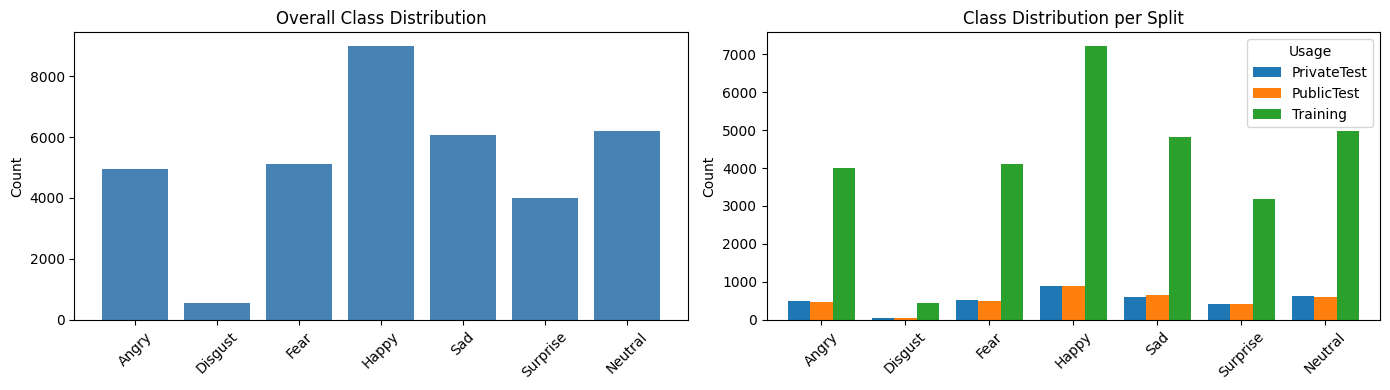


Observation: dataset is imbalanced - Disgust class is severely underrepresented


In [10]:
# 10. კლასის განაწილების ვიზუალიზაცია
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ზოგადი განაწილება
counts = df['emotion'].value_counts().sort_index()
axes[0].bar([EMOTION_LABELS[i] for i in counts.index], counts.values, color='steelblue')
axes[0].set_title('Overall Class Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

split_counts = df.groupby(['Usage', 'emotion']).size().unstack(fill_value=0)
split_counts.columns = [EMOTION_LABELS[c] for c in split_counts.columns]
split_counts.T.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('Class Distribution per Split')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Usage')

plt.tight_layout()
plt.show()

print("\nObservation: dataset is imbalanced - Disgust class is severely underrepresented")

In [11]:
# 11. Pixel string -> image conversion
def pixels_to_image(pixel_string):
    """Convert pixel string (space-separated values) to 48x48 numpy array"""
    pixels = np.array(pixel_string.split(), dtype=np.uint8)
    return pixels.reshape(48, 48)

# პირველ როუზე გატესტვა
first_image = pixels_to_image(df.iloc[0]['pixels'])
print(f"Image shape: {first_image.shape}")
print(f"dtype: {first_image.dtype}")
print(f"Min/Max: {first_image.min()}/{first_image.max()}")

Image shape: (48, 48)
dtype: uint8
Min/Max: 11/210


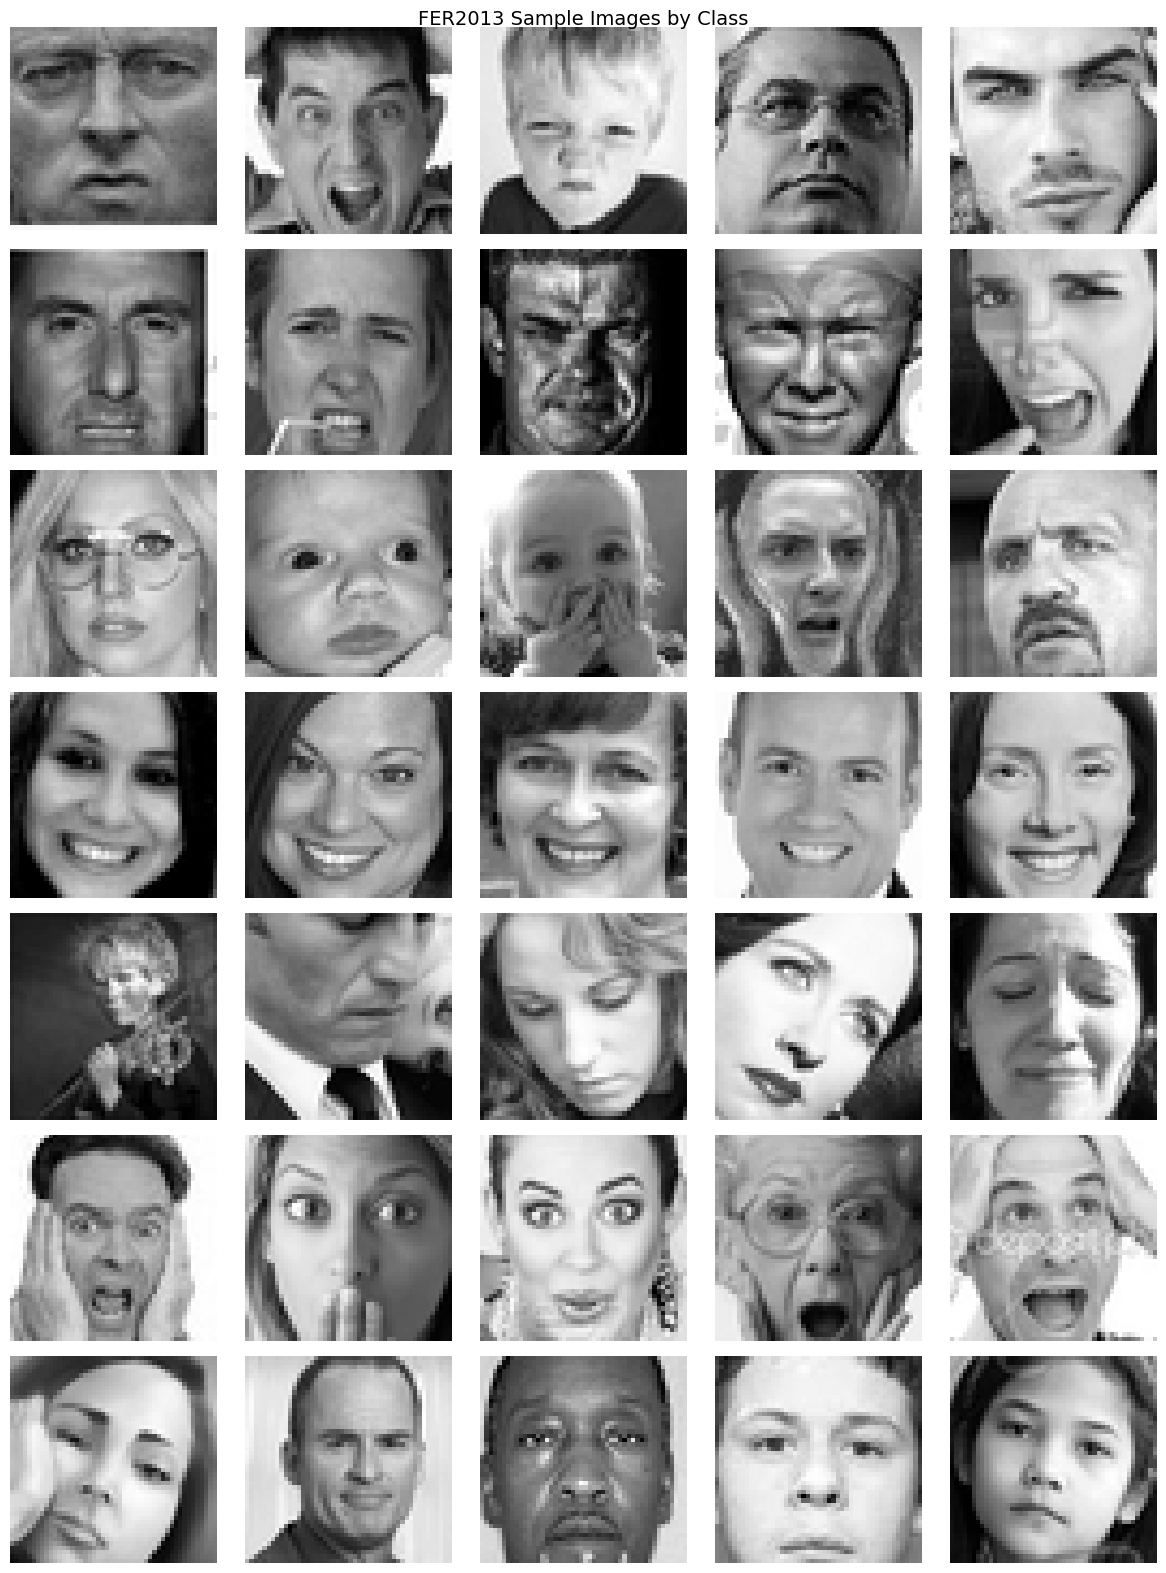

In [12]:
# 12. თითეული კლასის სამპლ იმიჯებზე
fig, axes = plt.subplots(7, 5, figsize=(12, 16))

for emotion_id in range(7):
    samples = df[df['emotion'] == emotion_id].sample(5, random_state=42)
    for i, (_, row) in enumerate(samples.iterrows()):
        img = pixels_to_image(row['pixels'])
        axes[emotion_id, i].imshow(img, cmap='gray')
        axes[emotion_id, i].axis('off')
        if i == 0:
            axes[emotion_id, i].set_ylabel(EMOTION_LABELS[emotion_id], fontsize=12, rotation=0, ha='right', va='center')

plt.suptitle('FER2013 Sample Images by Class', fontsize=14)
plt.tight_layout()
plt.show()

## Save Processed Data as numpy arrays


In [13]:
# 13. Convert all images to numpy arrays
print("Converting all images...")

# Split into train/val/test based on Usage column
train_df = df[df['Usage'] == 'Training'].reset_index(drop=True)
val_df = df[df['Usage'] == 'PublicTest'].reset_index(drop=True)
test_df = df[df['Usage'] == 'PrivateTest'].reset_index(drop=True)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

def df_to_arrays(d):
    X = np.stack([pixels_to_image(p) for p in d['pixels']])  # (N, 48, 48)
    y = d['emotion'].values.astype(np.int64)
    return X, y

X_train, y_train = df_to_arrays(train_df)
X_val, y_val = df_to_arrays(val_df)
X_test, y_test = df_to_arrays(test_df)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Converting all images...
Train: 28709, Val: 3589, Test: 3589
X_train shape: (28709, 48, 48), y_train shape: (28709,)
X_val shape: (3589, 48, 48), y_val shape: (3589,)
X_test shape: (3589, 48, 48), y_test shape: (3589,)


In [14]:
# 14. Save processed arrays
np.savez_compressed(
    f'{DATA_DIR}/fer2013_processed.npz',
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test
)

print(f"Saved to {DATA_DIR}/fer2013_processed.npz")
!ls -lh $DATA_DIR/fer2013_processed.npz

Saved to /content/drive/MyDrive/ML_davaleba_4/data/fer2013_processed.npz
-rw------- 1 root root 75M Jun 16 07:32 /content/drive/MyDrive/ML_davaleba_4/data/fer2013_processed.npz


In [15]:
# 15. Pixel statistics (for normalization in later notebooks)
print("Pixel statistics (training set):")
print(f"  Mean: {X_train.mean():.4f}")
print(f"  Std:  {X_train.std():.4f}")
print(f"  Min:  {X_train.min()}, Max: {X_train.max()}")

# Normalized statistics (after /255.0)
print("\nAfter /255 normalization:")
print(f"  Mean: {(X_train/255.0).mean():.4f}")
print(f"  Std:  {(X_train/255.0).std():.4f}")

Pixel statistics (training set):
  Mean: 129.4743
  Std:  65.0273
  Min:  0, Max: 255

After /255 normalization:
  Mean: 0.5077
  Std:  0.2550


## Summary
 Data downloaded and explored
